In [1]:
# ============================================================
# TEXT XAI RADAR PLOTS
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD CSV
# ------------------------------------------------------------

df = pd.read_csv("Explainability_Text.csv")

# ------------------------------------------------------------
# OUTPUT DIR
# ------------------------------------------------------------

SAVE_DIR = "/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# CLEAN MODEL NAMES
# ------------------------------------------------------------

DISPLAY_NAMES = {
    "bert": "BERT",
    "roberta": "RoBERTa",
    "gpt2": "GPT-2",
    "cliptext": "CLIP-Text"
}

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

metrics = [
    "faithfulness",
    "complexity",
    "sparsity",
    "rank_corr"
]

metric_titles = {
    "faithfulness": "Faithfulness",
    "complexity": "Entropy",
    "sparsity": "Stability",
    "rank_corr": "Rank Correlation"
}

# ------------------------------------------------------------
# GLOBAL NORMALIZATION
# IMPORTANT:
# normalize per metric for inter-model comparison
# ------------------------------------------------------------

df_norm = df.copy()

for m in metrics:
    df_norm[m] = (
        df[m] - df[m].min()
    ) / (
        df[m].max() - df[m].min() + 1e-8
    )

# ------------------------------------------------------------
# RADAR FUNCTION
# ------------------------------------------------------------

def radar_chart(df_norm, model_name):

    row = df_norm[df_norm["model"] == model_name].iloc[0]

    values = row[metrics].astype(float).values

    angles = np.linspace(
        0,
        2*np.pi,
        len(metrics),
        endpoint=False
    ).tolist()

    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [metric_titles[m] for m in metrics],
        fontsize=11
    )

    ax.set_yticklabels([])

    display_name = DISPLAY_NAMES.get(model_name, model_name)

    ax.set_title(
        f"Text Explainability Radar — {display_name}",
        fontsize=14,
        pad=20
    )

    plt.tight_layout()

    save_path = os.path.join(
        SAVE_DIR,
        f"{model_name}_radar.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {save_path}")

# ------------------------------------------------------------
# GENERATE ALL
# ------------------------------------------------------------

for m in df_norm["model"].unique():
    radar_chart(df_norm, m)

Saved: /home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots/bert_radar.png
Saved: /home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots/gpt2_radar.png
Saved: /home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots/roberta_radar.png


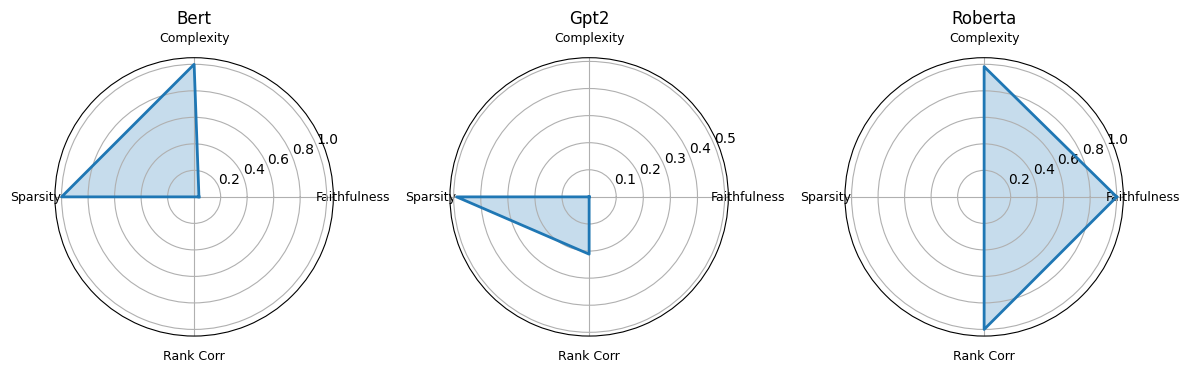

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

def radar_subplot(df, save_path=None):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    # normalisation globale (indispensable)
    df_norm = df.copy()
    for m in metrics:
        df_norm[m] = (df[m] - df[m].min()) / (df[m].max() - df[m].min() + 1e-8)

    models = df["model"].unique()

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        1, 3,
        subplot_kw=dict(polar=True),
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i, model in enumerate(models):

        row = df_norm[df_norm["model"] == model].iloc[0]
        values = row[metrics].values
        values = np.concatenate((values, [values[0]]))

        ax = axes[i]

        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)

        # Title propre
        ax.set_title(model.replace("_", " ").title(), fontsize=12)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([m.replace("_", " ").title() for m in metrics], fontsize=9)

    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, "radar_subplot_all_models.png"), dpi=300)

    plt.show()

# Example usage:
radar_subplot(df, save_path="/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots")

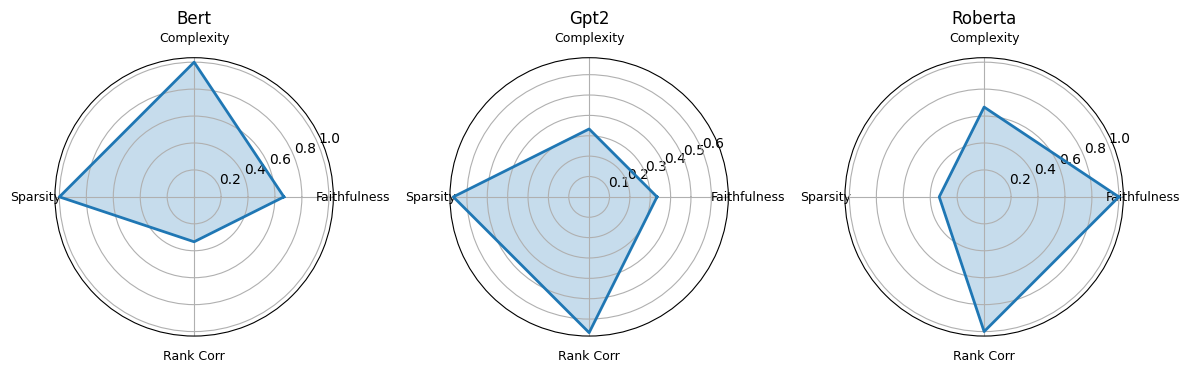

In [7]:
def radar_subplot(df, save_path=None):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    df_norm = df.copy()
    for m in metrics:
        df_norm[m] = df[m].rank(pct=True)   # ⭐ percentile normalization

    models = df["model"].unique()

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        1, len(models),
        subplot_kw=dict(polar=True),
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i, model in enumerate(models):

        row = df_norm[df_norm["model"] == model].iloc[0]
        values = row[metrics].values
        values = np.concatenate((values, [values[0]]))

        ax = axes[i]

        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)

        ax.set_title(model.title(), fontsize=12)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([m.replace("_", " ").title() for m in metrics], fontsize=9)

    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, "radar_subplot_all_models.png"), dpi=300)

    plt.show()

radar_subplot(df, save_path="/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots_normalized")

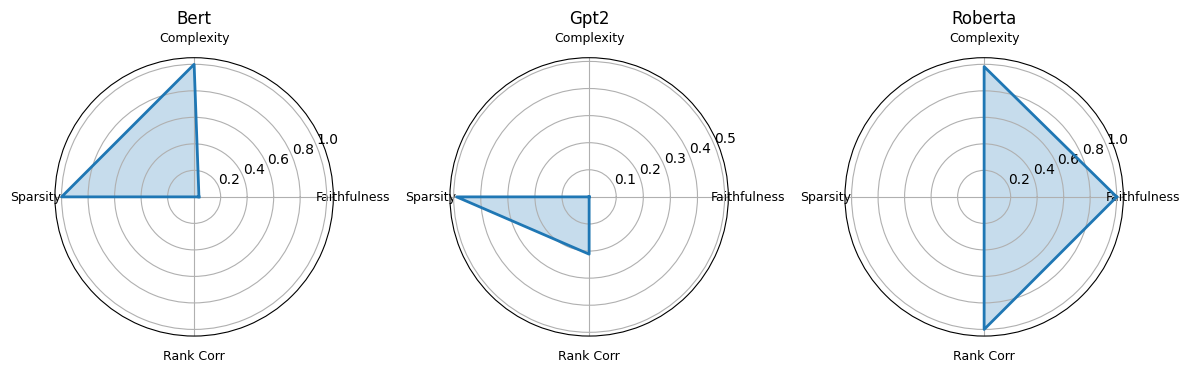

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

def radar_subplot(df, save_path=None):

    metrics = ["faithfulness", "complexity", "sparsity", "rank_corr"]

    # normalisation globale (indispensable)
    df_norm = df.copy()
    for m in metrics:
        df_norm[m] = (df[m] - df[m].min()) / (df[m].max() - df[m].min() + 1e-8)

    models = df["model"].unique()

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(
        1, 3,
        subplot_kw=dict(polar=True),
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i, model in enumerate(models):

        row = df_norm[df_norm["model"] == model].iloc[0]
        values = row[metrics].values
        values = np.concatenate((values, [values[0]]))

        ax = axes[i]

        ax.plot(angles, values, linewidth=2)
        ax.fill(angles, values, alpha=0.25)

        # Title propre
        ax.set_title(model.replace("_", " ").title(), fontsize=12)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([m.replace("_", " ").title() for m in metrics], fontsize=9)

    plt.tight_layout()

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(os.path.join(save_path, "radar_subplot_semantic_all_models.png"), dpi=300)

    plt.show()

# Example usage:
radar_subplot(df, save_path="/home/aysel/tfe/streamlit_app/data/unimodal/metrics/XAI_Text_Plots/Radar_Plots")

In [1]:
# ============================================================
# TEXT EXPLAINER AGREEMENT
# ============================================================

import pickle
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# ------------------------------------------------------------
# LOAD ATTRIBUTIONS
# ------------------------------------------------------------

with open("captum_text.pkl", "rb") as f:
    all_attrs_text = pickle.load(f)

# ------------------------------------------------------------
# AGREEMENT FUNCTION
# ------------------------------------------------------------

def attribution_similarity(a1, a2):

    a1 = a1.detach().cpu().numpy().flatten()
    a2 = a2.detach().cpu().numpy().flatten()

    corr, _ = spearmanr(a1, a2)

    return corr

# ------------------------------------------------------------
# COMPUTE AGREEMENTS
# ------------------------------------------------------------

rows = []

for entry in all_attrs_text:

    model_name = entry["model"]

    for item in entry["attrs"]:

        if "Saliency" not in item:
            continue

        ig  = item["IG"]
        sal = item["Saliency"]

        sim = attribution_similarity(ig, sal)

        rows.append({
            "model": model_name,
            "text_idx": item["text_idx"],
            "ig_saliency": sim
        })

df_agreement = pd.DataFrame(rows)

# ------------------------------------------------------------
# MODEL-LEVEL SUMMARY
# ------------------------------------------------------------

summary = (
    df_agreement
    .groupby("model")["ig_saliency"]
    .mean()
    .reset_index()
    .sort_values("ig_saliency", ascending=False)
)

print(summary)

summary.to_csv(
    "Text_Explainer_Agreement.csv",
    index=False
)

FileNotFoundError: [Errno 2] No such file or directory: 'captum_text.pkl'

In [5]:
# ============================================================
# TOKEN ATTRIBUTION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# VISUALIZATION FUNCTION
# ------------------------------------------------------------

def visualize_tokens(
    tokenizer,
    input_ids,
    attributions,
    title="Token Attribution"
):

    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.squeeze().tolist()
    )

    scores = attributions.squeeze().detach().cpu().numpy()

    scores = scores / (np.max(np.abs(scores)) + 1e-8)

    fig, ax = plt.subplots(figsize=(18, 4))

    ax.axis("off")

    x = 0.02
    y = 0.85

    for token, score in zip(tokens, scores):

        color = plt.cm.Reds(abs(score))

        text = ax.text(
            x,
            y,
            token,
            fontsize=11,
            transform=ax.transAxes,
            bbox=dict(
                facecolor=color,
                alpha=0.8,
                edgecolor="black",
                boxstyle="round,pad=0.25"
            )
        )

        renderer = fig.canvas.get_renderer()
        bb = text.get_window_extent(renderer=renderer)

        width = bb.width / fig.dpi / fig.get_size_inches()[0]

        x += width + 0.01

        # wrap line
        if x > 0.92:
            x = 0.02
            y -= 0.15

    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    
def normalize_name(name):
    return (
        name.lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )

models_text_norm = {
    normalize_name(k): v
    for k, v in models_text.items()
}


for entry in all_attrs_text:

    model_name = entry["model"]

    _, tok, _ = models_text_norm[
        normalize_name(model_name)
    ]

    item = entry["attrs"][0]

    input_ids = item["input_ids"][0]
    attr = item["IG"][0]

    visualize_tokens(
        tok,
        input_ids,
        attr,
        title=f"{model_name} — IG Attribution"
    )


NameError: name 'models_text' is not defined

In [ ]:
print(df_agreement.head())
print(df_agreement.columns)
print(len(df_agreement))

  model  text_idx  ig_saliency
0  BERT         0     0.990573
1  BERT         1     0.993113
2  BERT         2     0.987747
3  BERT         3     0.989535
4  BERT         4     0.988743
Index(['model', 'text_idx', 'ig_saliency'], dtype='str')
150
